# Photon Subtraction in Graph State
2026\. 05\. 19.  Make the pseudo code

##### Basic modules, parameters and functions

###### to be continued..

## 1. Set the graph state

##### Initial parameters, modules and functions

In [56]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph
Adj = np.array([[0, 1, 0, 0, 0, 0],
                [1, 0, 1, 1, 0, 0],
                [0, 1, 0, 0, 1, 0],
                [0, 1, 0, 0, 1, 0],
                [0, 0, 1, 1, 0, 1],
                [0, 0, 0, 0, 1, 0]], dtype=float)
m = Adj.shape[0]

# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m, 10, dtype=float) # 단위는 dB 
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 10 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
f_sub = np.array([1, 0, 0, 0, 0, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i
f_sub = f_sub / np.linalg.norm(f_sub) # 정규화
g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = Q(g_sub)+iQ(Jg_sub) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode

sub_label = "single mode 1" # just label for the plot later

In [57]:
def plot_graph_from_matrix(W, node_values=None, title="", threshold=1e-6, pos=None):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

#################################################
#data modification to make the graph look better#

    # W_plot = np.array(W, dtype=float).copy()

    # # plotting-only symmetrization
    # W_plot = 0.5 * (W_plot + W_plot.T)
    # # remove self-loops for plotting
    # np.fill_diagonal(W_plot, 0) 

    # # thresholding for plotting - W_plot의 절댓값이 threshold보다 큰 경우에만 edge로 그리도록 함
    # A_plot = np.where(np.abs(W_plot) > threshold, np.abs(W_plot), 0)
    
#     # create graph from adjacency matrix
#     G_plot = nx.from_numpy_array(A_plot)
# ################################################
# 이상적인 W가 아닐 경우, 위의 modification사용 # command + / (or Ctrl + / )로 주석 끄고 키기 가능
    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)



    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)

    # node label을 1부터 시작하게 바꿈
    labels = {i: i + 1 for i in range(W_plot.shape[0])}



    # plotting // 사이즈 고정
    plt.figure(figsize=(6, 4))
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="black",
        width=2
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            node_size=700
        )
    else:
        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values,
            cmap="viridis",#viridis, plasma, inferno, magma, cividis 등 다양한 colormap 사용 가능(지금은 비리디스)
            edgecolors="black",
            node_size=700
        )
        plt.colorbar(nodes)

    # graph label 그리기
    nx.draw_networkx_labels(
        G_plot,
        pos,
        labels=labels,
        font_color="black"
    )

    plt.title(title)
    plt.axis("equal")
    plt.axis("off")
    plt.show()

    return pos

##### Graph-State Sanity

In [58]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 6
Adj =
 [[0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]
V =
 [[10.   0.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0. ]
 [ 0.  10.   0.   0.   0.   0.  10.   0.  10.  10.   0.   0. ]
 [ 0.   0.  10.   0.   0.   0.   0.  10.   0.   0.  10.   0. ]
 [ 0.   0.   0.  10.   0.   0.   0.  10.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.  10.   0.   0.   0.  10.  10.   0.  10. ]
 [ 0.   0.   0.   0.   0.  10.   0.   0.   0.   0.  10.   0. ]
 [ 0.  10.   0.   0.   0.   0.  10.1  0.  10.  10.   0.   0. ]
 [10.   0.  10.  10.   0.   0.   0.  30.1  0.   0.  20.   0. ]
 [ 0.  10.   0.   0.  10.   0.  10.   0.  20.1 20.   0.  10. ]
 [ 0.  10.   0.   0.  10.   0.  10.   0.  20.  20.1  0.  10. ]
 [ 0.   0.  10.  10.   0.  10.   0.  20.   0.   0.  30.1  0. ]
 [ 0.   0.   0.   0.  10.   0.   0.   0.  10.  10.   0.  10.1]]
f_sub = [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
f_sub shape = (6,)
physical covariance(V + iOm

chosen: p - Γx
nullifier variances = [0.1 0.1 0.1 0.1 0.1 0.1]
below vacuum: [ True  True  True  True  True  True]
Adj_eff =
 [[0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]


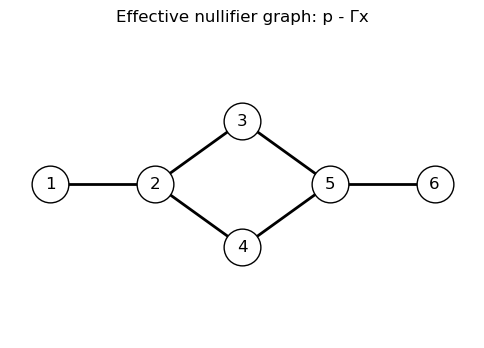

In [60]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))
pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos=  
    {
    0: (0.0, 0.0),
    1: (1.5, 0.0),
    2: (2.75, 0.9),
    3: (2.75, -0.9),
    4: (4.0, 0.0),
    5: (5.5, 0.0),
    }
)